In [233]:
import numpy as np
import matplotlib.pyplot as plt

# Cost Comparison

This notebook visualizes the total cost for different interruption handling strategies.

In [234]:
# Cost data ($)
costs = {
    'On-demand Only': 27.16,
    'ShuntServe': 18.19,
    'Concurrent Initialization': 18.19,
    'Request Migration': 17.06,
    'No Handle': 17.06
}

print("Total Cost ($):")
for k, v in costs.items():
    print(f"  {k}: ${v:.2f}")

Total Cost ($):
  On-demand Only: $27.16
  ShuntServe: $18.19
  Concurrent Initialization: $18.19
  Request Migration: $17.06
  No Handle: $17.06


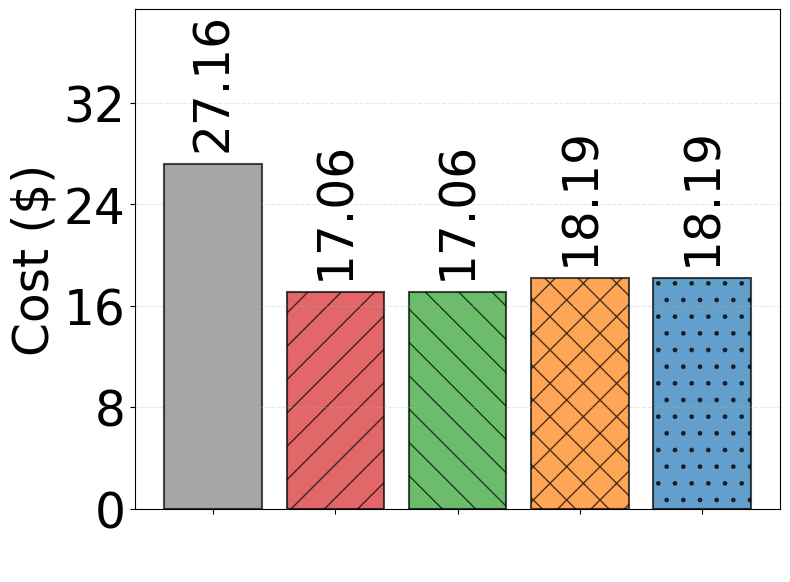


Saved: cost_comparison.pdf


In [235]:
# Define order: On-demand first, then reverse the rest
order = ['On-demand\nOnly', 'No\nHandle', 'Request\nMigration', 'Concurrent\nInitialization', 'ShuntServe']

# Extract values in order (using original keys without newlines)
order_keys = ['On-demand Only', 'No Handle', 'Request Migration', 'Concurrent Initialization', 'ShuntServe']
values = [costs[k] for k in order_keys]

# Colors matching the new order
colors = ['#808080', '#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']

# Hatch patterns for each approach (less dense)
hatches = ['', '/', '\\', 'x', '.']

# Font size control
fontsize = 35

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create bars with different hatch patterns
bars = []
for i, (val, color, hatch) in enumerate(zip(values, colors, hatches)):
    bar = ax.bar(i, val, width=0.8, color=color, alpha=0.7, edgecolor='black', linewidth=1.5, hatch=hatch)
    bars.append(bar)

# Add value labels on bars with spacing
for i, (bar_container, val) in enumerate(zip(bars, values)):
    bar = bar_container[0]
    height = bar.get_height()
    
    # Add cost value on top with offset for spacing
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.0,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=fontsize, rotation=90)

# Customize plot
ax.set_ylabel('Cost ($)', fontsize=fontsize)

# Customize plot
ax.set_xticks(range(len(order)))
ax.set_xticklabels([])  # Remove x labels
ax.set_xlabel(' ', fontsize=fontsize)  # Empty space for height alignment
ax.set_ylim(0, max(values) * 1.45)
ax.text(0.5, 1.15, '', transform=ax.transAxes)  # Spacing for alignment
ax.tick_params(axis='y', labelsize=fontsize)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Use fewer y-axis ticks (nbins parameter controls number of ticks)
from matplotlib.ticker import MaxNLocator
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

plt.tight_layout()
plt.savefig('cost_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: cost_comparison.pdf")

# Cost Efficiency Comparison (Normalized)

Compares throughput cost efficiency and latency cost efficiency, both normalized to On-demand Only baseline.

In [236]:
# Throughput cost efficiency (RPS/$) - higher is better
throughput_cost_efficiency = {
    'On-demand Only': 0.0503,
    'ShuntServe': 0.0609,
    'Concurrent Initialization': 0.0561,
    'Request Migration': 0.0552,
    'No Handle': 0.0485
}

# Latency cost efficiency (sec·$) - lower is better
latency_cost_product = {
    'On-demand Only': 14743.76,
    'ShuntServe': 11424.32,
    'Concurrent Initialization': 13744.41,
    'Request Migration': 15346.84,
    'No Handle': 18311.05
}

print("Throughput Cost Efficiency (RPS/$):")
for k, v in throughput_cost_efficiency.items():
    print(f"  {k}: {v:.4f}")

print("\nLatency × Cost (sec·$):")
for k, v in latency_cost_product.items():
    print(f"  {k}: {v:.2f}")

Throughput Cost Efficiency (RPS/$):
  On-demand Only: 0.0503
  ShuntServe: 0.0609
  Concurrent Initialization: 0.0561
  Request Migration: 0.0552
  No Handle: 0.0485

Latency × Cost (sec·$):
  On-demand Only: 14743.76
  ShuntServe: 11424.32
  Concurrent Initialization: 13744.41
  Request Migration: 15346.84
  No Handle: 18311.05


In [237]:
# Define order: On-demand first, then reverse the rest (with newlines)
order = ['On-demand\nOnly', 'No\nHandle', 'Request\nMigration', 'Concurrent\nInitialization', 'ShuntServe']
order_keys = ['On-demand Only', 'No Handle', 'Request Migration', 'Concurrent Initialization', 'ShuntServe']

# Extract values
throughput_eff_values = [throughput_cost_efficiency[k] for k in order_keys]
latency_cost_values = [latency_cost_product[k] for k in order_keys]

# Normalize to On-demand Only (first value)
throughput_baseline = throughput_eff_values[0]
latency_baseline = latency_cost_values[0]

# For throughput: higher is better, so normalize directly
throughput_normalized = [v / throughput_baseline for v in throughput_eff_values]

# For latency cost: lower is better, so take inverse then normalize
# This makes higher values better (consistent with throughput)
latency_inverse = [1 / v for v in latency_cost_values]
latency_inverse_baseline = latency_inverse[0]
latency_normalized = [v / latency_inverse_baseline for v in latency_inverse]

print("Normalized Throughput Cost Efficiency (vs On-demand):")
for approach, norm_val in zip(order_keys, throughput_normalized):
    print(f"  {approach}: {norm_val:.3f}x")

print("\nNormalized Latency Cost Efficiency (vs On-demand, inverse):")
for approach, norm_val in zip(order_keys, latency_normalized):
    print(f"  {approach}: {norm_val:.3f}x")

Normalized Throughput Cost Efficiency (vs On-demand):
  On-demand Only: 1.000x
  No Handle: 0.964x
  Request Migration: 1.097x
  Concurrent Initialization: 1.115x
  ShuntServe: 1.211x

Normalized Latency Cost Efficiency (vs On-demand, inverse):
  On-demand Only: 1.000x
  No Handle: 0.805x
  Request Migration: 0.961x
  Concurrent Initialization: 1.073x
  ShuntServe: 1.291x


In [238]:
# # Colors matching the new order: On-demand, No Handle, Request Migration, Concurrent Init, ShuntServe
# colors = ['#808080', '#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']

# # Font size control
# fontsize = 16

# # Create figure with grouped bars
# fig, ax = plt.subplots(figsize=(12, 6))

# x_pos = np.arange(len(order))
# bar_width = 0.35

# # Create grouped bars
# bars1 = ax.bar(x_pos - bar_width/2, throughput_normalized, bar_width, 
#                label='Throughput / Cost [Offline]', color=colors, alpha=0.7, 
#                edgecolor='black', linewidth=1.5)

# bars2 = ax.bar(x_pos + bar_width/2, latency_normalized, bar_width,
#                label='1 / (Latency × Cost) [Online]', color=colors, alpha=0.5, 
#                edgecolor='black', linewidth=1.5, hatch='//')

# # Add value labels on bars
# for i, (bar, norm_val) in enumerate(zip(bars1, throughput_normalized)):
#     height = bar.get_height()
#     label = f'{norm_val:.2f}x' if i > 0 else '1.00x'
#     ax.text(bar.get_x() + bar.get_width()/2., height,
#             label, ha='center', va='bottom', fontsize=fontsize-2)

# for i, (bar, norm_val) in enumerate(zip(bars2, latency_normalized)):
#     height = bar.get_height()
#     label = f'{norm_val:.2f}x' if i > 0 else '1.00x'
#     ax.text(bar.get_x() + bar.get_width()/2., height,
#             label, ha='center', va='bottom', fontsize=fontsize-2)

# # Customize plot
# ax.set_ylabel('Normalized Efficiency (Higher is Better)', fontsize=fontsize)
# ax.set_xticks(x_pos)
# ax.set_xticklabels(order, fontsize=fontsize, rotation=15, ha='center')
# max_val = max(max(throughput_normalized), max(latency_normalized))
# ax.set_ylim(0, max_val * 1.25)
# ax.tick_params(axis='y', labelsize=fontsize)
# ax.grid(True, axis='y', alpha=0.3, linestyle='--')
# ax.legend(fontsize=fontsize-2, loc='upper left', ncol=2)

# plt.tight_layout()
# plt.savefig('cost_efficiency_comparison_grouped.pdf', dpi=300, bbox_inches='tight')
# plt.show()

# print("\nSaved: cost_efficiency_comparison_grouped.pdf")

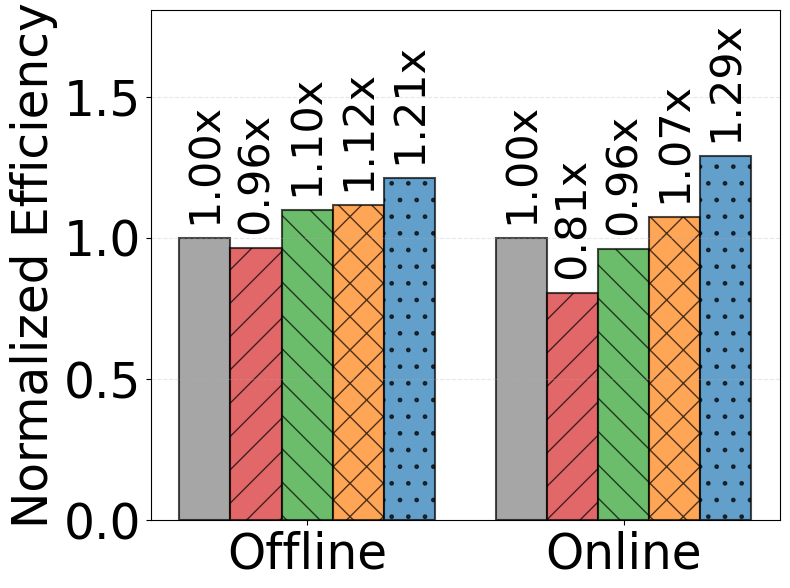


Saved: cost_efficiency_comparison_metric_grouped.pdf


In [239]:
# Create figure with metric-based grouping
# Group 1: All approaches for Throughput
# Group 2: All approaches for Latency

# Colors for each approach (same as before)
colors = ['#808080', '#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']

# Hatch patterns for each approach (less dense)
hatches = ['', '/', '\\', 'x', '.']

# Font size control
fontsize = 35
fig, ax = plt.subplots(figsize=(8, 6))

n_approaches = len(order)
n_groups = 2
bar_width = 0.25
group_width = n_approaches * bar_width
group_gap = 0.3

# Position calculation
# Group 1 (Throughput): centered at 0
# Group 2 (Latency): centered at (group_width + group_gap)
group1_center = (n_approaches - 1) * bar_width / 2
group2_center = group1_center + group_width + group_gap

# Create bars for Throughput group
throughput_positions = [i * bar_width for i in range(n_approaches)]
bars1 = []
for i, (pos, val, color, hatch) in enumerate(zip(throughput_positions, throughput_normalized, colors, hatches)):
    bar = ax.bar(pos, val, bar_width, 
                 color=color, alpha=0.7, 
                 edgecolor='black', linewidth=1.5, hatch=hatch)
    bars1.append(bar)
    
    # Add value label with more spacing from bar
    height = val
    label = f'{val:.2f}x' if i > 0 else '1.00x'
    # Add 0.05 offset for spacing
    ax.text(pos, height + 0.05, label, ha='center', va='bottom', fontsize=fontsize-4, rotation=90)

# Create bars for Latency group
latency_positions = [group_width + group_gap + i * bar_width for i in range(n_approaches)]
bars2 = []
for i, (pos, val, color, hatch) in enumerate(zip(latency_positions, latency_normalized, colors, hatches)):
    bar = ax.bar(pos, val, bar_width,
                 color=color, alpha=0.7, 
                 edgecolor='black', linewidth=1.5, hatch=hatch)
    bars2.append(bar)
    
    # Add value label with more spacing from bar
    height = val
    label = f'{val:.2f}x' if i > 0 else '1.00x'
    # Add 0.05 offset for spacing
    ax.text(pos, height + 0.05, label, ha='center', va='bottom', fontsize=fontsize-4, rotation=90)

# Customize plot
ax.set_ylabel('Normalized Efficiency', fontsize=fontsize)

# Set x-ticks at group centers
ax.set_xticks([group1_center, group2_center])
ax.set_xticklabels(['Offline', 'Online'], fontsize=fontsize)

max_val = max(max(throughput_normalized), max(latency_normalized))
ax.set_ylim(0, max_val * 1.4)  # Increased to accommodate vertical text
ax.tick_params(axis='y', labelsize=fontsize)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')




plt.tight_layout()
plt.savefig('cost_efficiency_comparison_metric_grouped.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: cost_efficiency_comparison_metric_grouped.pdf")

/var/folders/zh/42llgg8s6gz6rjh2s2z_x7900000gn/T/ipykernel_2647/735216146.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


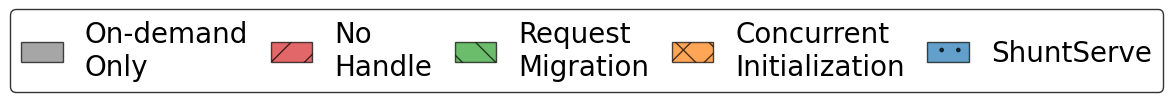

Saved: cost_efficiency_legend.pdf


In [240]:
# Legend for Cost Efficiency Comparison
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colors for each approach
colors = ['#808080', '#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']
labels = ['On-demand\nOnly', 'No\nHandle', 'Request\nMigration', 'Concurrent\nInitialization', 'ShuntServe']

# Hatch patterns for each approach (less dense)
hatches = ['', '/', '\\', 'x', '.']

# Font size control
fontsize = 20

fig, ax = plt.subplots(figsize=(10, 0.5))
ax.axis('off')

# Create legend elements with hatch patterns
legend_elements = [mpatches.Patch(facecolor=color, edgecolor='black', label=label, alpha=0.7, hatch=hatch)
                   for color, label, hatch in zip(colors, labels, hatches)]

# Create legend with tighter spacing and smaller handle
legend = ax.legend(handles=legend_elements, fontsize=fontsize, loc='center', ncol=5,
                   columnspacing=0.8, handlelength=1.5, edgecolor='black')

plt.tight_layout()
plt.savefig('cost_efficiency_legend.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print("Saved: cost_efficiency_legend.pdf")